# Notebook 13: LSTM Gentrification Prediction Prototype

**Objective:** Build a PyTorch LSTM that predicts gentrification class (0/1/2) per neighborhood cluster from temporal CVR business data.  
Spatial-join 341K business points to 1,421 clusters, aggregate industry counts per 5-year window (6 time steps), learn DB25 embeddings, and train an LSTM classifier — directly comparable with the XGBoost baseline (Notebook 05).

**Phases:**
1. Data Pipeline & Storage
2. Feature Engineering & Embeddings
3. PyTorch LSTM Model & Training

## Phase 1 — Data Pipeline

In [2]:
# Cell 1: Imports & config
import os, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore", category=FutureWarning)

# ── Paths (relative from notebooks/) ──
CVR_GEO_PATH       = Path("../data/processed/cvr/CVR_geo_temporal.geojson")
#CLUSTER_SHP_PATH   = Path("../data/raw/neighborhood_shapefile/Nabolag_cph_fre_new.shp")
CLUSTER_SHP_PATH   = Path("../data/raw/nabolag_inkl_y_kom_shapefile/cluster_outer_v1.shp") # change between different clister setup
STA_DATA_PATH      = Path("../data/interim/STA_data.csv")
PARQUET_OUT_PATH   = Path("../data/processed/cvr/cvr_cluster_temporal_counts.parquet")
MODEL_OUT_PATH     = Path("../results/models/lstm_gentrification.pt")
PRED_OUT_PATH      = Path("../results/models/lstm_predictions.csv")

# ── Temporal periods (matching XGBoost notebook 05) ──
PERIODS = [
    (1990, 1995),
    (1995, 2000),
    (2000, 2005),
    (2005, 2010),
    (2010, 2015),
    (2015, 2020),
]
NUM_PERIODS = len(PERIODS)

# ── Reproducibility ──
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | Device: {DEVICE}")

PyTorch 2.11.0+cpu | Device: cpu


In [3]:
# Cell 2: Load CVR GeoJSON, parse dates, reproject to EPSG:25832
print("Loading CVR_geo_temporal.geojson ...")
cvr_gdf = gpd.read_file(CVR_GEO_PATH)
print(f"Loaded {len(cvr_gdf):,} business features | CRS: {cvr_gdf.crs}")

# Parse dates
for col in ["produktionsenhedStartdato", "produktionsenhedOphoersdato",
            "virksomhedStartdato", "virksomhedOphoersdato"]:
    if col in cvr_gdf.columns:
        cvr_gdf[col] = pd.to_datetime(cvr_gdf[col], errors="coerce")

# Use produktionsenhed dates as primary; fall back to virksomhed dates
cvr_gdf["start_date"] = cvr_gdf["produktionsenhedStartdato"].fillna(
    cvr_gdf["virksomhedStartdato"]
)
cvr_gdf["end_date"] = cvr_gdf["produktionsenhedOphoersdato"].fillna(
    cvr_gdf["virksomhedOphoersdato"]
)

# Reproject WGS84 → EPSG:25832
if cvr_gdf.crs is None or cvr_gdf.crs.to_epsg() != 25832:
    cvr_gdf = cvr_gdf.to_crs(epsg=25832)
    print(f"Reprojected to EPSG:25832")

# Drop rows without geometry
before = len(cvr_gdf)
cvr_gdf = cvr_gdf[cvr_gdf.geometry.notna()].copy()
print(f"Dropped {before - len(cvr_gdf):,} rows with null geometry → {len(cvr_gdf):,} remaining")

# Use full 6-digit DB25 code (branche_kode) instead of 2-digit prefix
cvr_gdf["db25"] = cvr_gdf["branche_kode"].astype(str).str.strip()
print(f"Unique 6-digit DB25 codes: {cvr_gdf['db25'].nunique()}")
cvr_gdf.head(3)

Loading CVR_geo_temporal.geojson ...


c:\Users\jonas\Desktop\7_semester\Projekt\Gentrification_model\.venv\Lib\site-packages\geopandas\io\file.py:576: UserWarning: Error parsing datetimes, original strings are returned: Out of bounds nanosecond timestamp: 0082-11-01, at position 9684. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)
c:\Users\jonas\Desktop\7_semester\Projekt\Gentrification_model\.venv\Lib\site-packages\geopandas\io\file.py:576: UserWarning: Error parsing datetimes, original strings are returned: Out of bounds nanosecond timestamp: 0082-11-01, at position 4816. You might want to try:
    - passing `format` if your strings have a consistent format;
   

Loaded 332,071 business features | CRS: EPSG:4326
Reprojected to EPSG:25832
Dropped 0 rows with null geometry → 332,071 remaining
Unique 6-digit DB25 codes: 1574


,CVRNummer,navn,virksomhedStartdato,virksomhedOphoersdato,branche_kode,branche_navn,CVREnhedsId,Adresse,pNummer,tilknyttetVirksomhedsCVRNummer,produktionsenhedStartdato,produktionsenhedOphoersdato,geometry,start_date,end_date,db25
0,13412731,CARNEGIE ASSET ADMINISTRATION A/S,1989-08-01,2019-06-11,661900,Andre hjælpetjenester i forbindelse med finans...,4002799827,d8f92e9d-db74-45b0-89b2-973686e16809,1000558874,13412731,1989-08-01,2019-06-11,POINT (725925.52 6178533.39),1989-08-01,2019-06-11,661900
1,40240918,PLANICO ApS,1972-05-16,NaT,692000,Bogføring og revision; skatterådgivning,4002318166,0a3f50a4-14d9-32b8-e044-0003ba298018,1001793715,40240918,2000-01-28,NaT,POINT (721134.21 6184230.03),2000-01-28,NaT,692000
2,81090416,"ERIK CHRISTENSEN & SØN, BIRKERØD A/S",1977-11-04,NaT,511100,"Agenturhandel med råvarer til landbruget, land...",4003147554,c44181eb-7625-4844-93ce-6fde4d89e444,1002971450,81090416,1991-01-01,2010-11-25,POINT (724033.54 6174859),1991-01-01,2010-11-25,511100


In [4]:
# Cell 3: Spatial join — assign cluster_id to each business
print("Loading cluster polygons ...")
clusters = gpd.read_file(CLUSTER_SHP_PATH)
print(f"Loaded {len(clusters):,} cluster polygons | CRS: {clusters.crs}")
print(f"Columns: {list(clusters.columns)}")

# Pick the right join key (avoid duplicate after rename)
if "munic_clus" in clusters.columns:
    join_key = "munic_clus"
elif "cluster_id" in clusters.columns:
    join_key = "cluster_id"
else:
    raise KeyError("No munic_clus or cluster_id column found in shapefile")

# Keep only the join key + geometry, then rename to cluster_id
clusters_slim = clusters[[join_key, "geometry"]].copy()
clusters_slim = clusters_slim.rename(columns={join_key: "cluster_id"})

# Spatial join (inner keeps only businesses inside a polygon)
print("Running spatial join ...")
cvr_joined = gpd.sjoin(cvr_gdf, clusters_slim, how="inner", predicate="within")

match_rate = len(cvr_joined) / len(cvr_gdf) * 100
print(f"Matched {len(cvr_joined):,} / {len(cvr_gdf):,} businesses ({match_rate:.1f}%)")
print(f"Businesses assigned to {cvr_joined['cluster_id'].nunique()} unique clusters")

Loading cluster polygons ...
Loaded 2,232 cluster polygons | CRS: EPSG:25832
Columns: ['fid', 'munic_code', 'id_munic', 'area', 'cluster_id', 'geometry']
Running spatial join ...
Matched 276,010 / 332,071 businesses (83.1%)
Businesses assigned to 2224 unique clusters


In [5]:
# Cell 4: Temporal bucketing — determine which periods each business was active
def assign_periods(row):
    """Return list of period indices where the business was active."""
    start = row["start_date"]
    end   = row["end_date"]
    start_year = start.year if pd.notna(start) else 1900
    end_year   = end.year   if pd.notna(end)   else 2026  # still active
    active = []
    for i, (p_start, p_end) in enumerate(PERIODS):
        if start_year < p_end and end_year >= p_start:
            active.append(i)
    return active

print("Assigning businesses to 5-year periods ...")
cvr_joined["active_periods"] = cvr_joined.apply(assign_periods, axis=1)

# Explode so each row = one business × one period
cvr_exploded = cvr_joined.explode("active_periods")
cvr_exploded = cvr_exploded.dropna(subset=["active_periods"])
cvr_exploded["period_idx"] = cvr_exploded["active_periods"].astype(int)

print(f"Exploded to {len(cvr_exploded):,} business-period rows")
print(f"Period distribution:")
for i, (ps, pe) in enumerate(PERIODS):
    n = (cvr_exploded["period_idx"] == i).sum()
    print(f"  {ps}-{pe}: {n:,} active businesses")

Assigning businesses to 5-year periods ...
Exploded to 567,320 business-period rows
Period distribution:
  1990-1995: 28,325 active businesses
  1995-2000: 48,577 active businesses
  2000-2005: 75,883 active businesses
  2005-2010: 96,773 active businesses
  2010-2015: 130,338 active businesses
  2015-2020: 187,424 active businesses


In [6]:
# Cell 5: Aggregate — count businesses per (cluster_id, period, db25) + gentrified flag
# ── Load gentrified industry codes ──
GENT_IND_PATH = Path("../data/raw/cvr_raw/industry_ids/Gentrified_business_certain_industry_id.csv")
gent_df = pd.read_csv(GENT_IND_PATH, sep=";", encoding="latin-1")
gent_codes = set(gent_df["industry-id"].astype(str).str.strip())
print(f"Loaded {len(gent_codes)} gentrified industry codes")

# Flag each business as gentrified or not (match on full 6-digit branche_kode)
cvr_exploded["is_gentrified"] = cvr_exploded["db25"].isin(gent_codes).astype(int)
gent_rate = cvr_exploded["is_gentrified"].mean()
print(f"Gentrified businesses: {cvr_exploded['is_gentrified'].sum():,} / {len(cvr_exploded):,} ({gent_rate:.1%})")

# ── DB25 6-digit counts per cluster × period ──
print("Aggregating business counts per cluster × period × DB25 6-digit code ...")
agg = (
    cvr_exploded
    .groupby(["cluster_id", "period_idx", "db25"])
    .size()
    .reset_index(name="count")
)

pivot = agg.pivot_table(
    index=["cluster_id", "period_idx"],
    columns="db25",
    values="count",
    fill_value=0,
).reset_index()

db25_cols = [c for c in pivot.columns if c not in ("cluster_id", "period_idx")]
pivot.columns.name = None
pivot["total_businesses"] = pivot[db25_cols].sum(axis=1)

# ── Gentrified business counts per cluster × period ──
gent_agg = (
    cvr_exploded
    .groupby(["cluster_id", "period_idx"])["is_gentrified"]
    .agg(gentrified_count="sum", gentrified_ratio="mean")
    .reset_index()
)
pivot = pivot.merge(gent_agg, on=["cluster_id", "period_idx"], how="left")
pivot["gentrified_count"] = pivot["gentrified_count"].fillna(0)
pivot["gentrified_ratio"] = pivot["gentrified_ratio"].fillna(0)

print(f"Aggregated shape: {pivot.shape}")
print(f"DB25 6-digit columns: {len(db25_cols)}")
print(f"Unique clusters in aggregation: {pivot['cluster_id'].nunique()}")
print(f"Extra columns: gentrified_count, gentrified_ratio")
pivot.head()

Loaded 21 gentrified industry codes
Gentrified businesses: 12,002 / 567,320 (2.1%)
Aggregating business counts per cluster × period × DB25 6-digit code ...
Aggregated shape: (13211, 1520)
DB25 6-digit columns: 1515
Unique clusters in aggregation: 2224
Extra columns: gentrified_count, gentrified_ratio


,cluster_id,period_idx,011100,011110,011190,011210,011220,011300,011600,011900,...,981000,982000,990000,990010,990020,999999,None,total_businesses,gentrified_count,gentrified_ratio
0,101_1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0,0.0
1,101_1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,8.0,0,0.0
2,101_1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,7.0,0,0.0
3,101_1,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,19.0,0,0.0
4,101_1,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.0,35.0,0,0.0


In [7]:
# Cell 6: Save to Parquet + verify coverage
PARQUET_OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
pivot.to_parquet(PARQUET_OUT_PATH, index=False)
print(f"Saved aggregated data to {PARQUET_OUT_PATH} ({PARQUET_OUT_PATH.stat().st_size/1024:.0f} KB)")

# Load target labels to check coverage
sta = pd.read_csv(STA_DATA_PATH)
target_clusters = set(sta["cluster_id"].astype(str))
agg_clusters = set(pivot["cluster_id"].astype(str))

covered = target_clusters & agg_clusters
missing = target_clusters - agg_clusters
print(f"\nTarget clusters (STA_data): {len(target_clusters)}")
print(f"Clusters with CVR data:     {len(agg_clusters)}")
print(f"Overlap:                    {len(covered)} ({len(covered)/len(target_clusters)*100:.1f}%)")
if missing:
    print(f"Missing clusters (no CVR data): {len(missing)}")

# Class distribution in target
print(f"\nTarget class distribution (mean_sd_class_idx):")
print(sta["mean_sd_class_idx"].value_counts().sort_index())

Saved aggregated data to ..\data\processed\cvr\cvr_cluster_temporal_counts.parquet (1455 KB)

Target clusters (STA_data): 1421
Clusters with CVR data:     2224
Overlap:                    1421 (100.0%)

Target class distribution (mean_sd_class_idx):
mean_sd_class_idx
0    253
1    911
2    257
Name: count, dtype: int64


## Phase 2 — Feature Engineering & Dataset

In [8]:
# Cell 7: Build sequence tensors
# Reload from Parquet (allows skipping Phase 1 on re-runs)
pivot = pd.read_parquet(PARQUET_OUT_PATH)
sta = pd.read_csv(STA_DATA_PATH)

# Identify feature columns (all DB25 6-digit codes + summary cols)
meta_cols = ["cluster_id", "period_idx"]
non_db25 = {"total_businesses", "gentrified_count", "gentrified_ratio"}
feature_cols = [c for c in pivot.columns if c not in meta_cols]
print(f"Feature columns ({len(feature_cols)}): {feature_cols[:10]} ...")

# Build DB25 vocabulary for embedding — exclude non-DB25 summary columns
db25_cols = [c for c in feature_cols if c not in non_db25]
db25idx = {code: i for i, code in enumerate(sorted(db25_cols))}
idx2db25 = {i: code for code, i in db25idx.items()}
NUM_DB25 = len(db25idx)
print(f"DB25 vocabulary: {NUM_DB25} unique 6-digit codes")
print(f"Non-DB25 feature columns kept: {sorted(non_db25 & set(feature_cols))}")

# ── Drop sparse DB25 columns (>95% zeros → noise, not signal) ──
db25_sparsity = {c: (pivot[c] == 0).mean() for c in db25_cols}
sparse_cols = [c for c, s in db25_sparsity.items() if s > 0.95]
kept_db25 = [c for c in db25_cols if c not in sparse_cols]
print(f"Dropping {len(sparse_cols)} sparse DB25 columns (>95% zeros): {sparse_cols[:10]}{'...' if len(sparse_cols)>10 else ''}")
print(f"Keeping {len(kept_db25)} DB25 columns")

# Update feature_cols and db25_cols after filtering
db25_cols = kept_db25
feature_cols = db25_cols + sorted(non_db25 & set(feature_cols))
db25idx = {code: i for i, code in enumerate(sorted(db25_cols))}
idx2db25 = {i: code for code, i in db25idx.items()}
NUM_DB25 = len(db25idx)

# Ensure all clusters have all 6 periods (fill missing periods with zeros)
all_clusters = sorted(pivot["cluster_id"].unique())
all_periods = list(range(NUM_PERIODS))

full_index = pd.MultiIndex.from_product(
    [all_clusters, all_periods], names=["cluster_id", "period_idx"]
)
pivot_full = (
    pivot.set_index(["cluster_id", "period_idx"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)
print(f"Full matrix: {pivot_full.shape[0]} rows = {len(all_clusters)} clusters × {NUM_PERIODS} periods")
print(f"Final feature count: {len(feature_cols)}")

Feature columns (1518): ['011100', '011110', '011190', '011210', '011220', '011300', '011600', '011900', '012100', '012110'] ...
DB25 vocabulary: 1515 unique 6-digit codes
Non-DB25 feature columns kept: ['gentrified_count', 'gentrified_ratio', 'total_businesses']
Dropping 1372 sparse DB25 columns (>95% zeros): ['011100', '011110', '011190', '011210', '011220', '011300', '011600', '011900', '012100', '012110']...
Keeping 143 DB25 columns
Full matrix: 13344 rows = 2224 clusters × 6 periods
Final feature count: 146


In [9]:
# Cell 8: Prepare target labels + train/val/test split
# ── REGRESSION approach: use continuous 'mean' instead of class index ──
sta["cluster_id"] = sta["cluster_id"].astype(str)
pivot_full["cluster_id"] = pivot_full["cluster_id"].astype(str)

# Only keep clusters that exist in both datasets
valid_clusters = sorted(
    set(pivot_full["cluster_id"].unique()) & set(sta["cluster_id"].unique())
)
print(f"Clusters with both CVR data and target label: {len(valid_clusters)}")

# Build target maps — both continuous (for training) and class (for evaluation)
target_map = sta.set_index("cluster_id")["mean_sd_class_idx"].to_dict()
target_map_cont = sta.set_index("cluster_id")["mean"].to_dict()

y_all_class = np.array([int(target_map[c]) for c in valid_clusters])
y_all_cont  = np.array([float(target_map_cont[c]) for c in valid_clusters])

# Stratified split on CLASS labels (keeps balanced evaluation) but train on continuous
train_clusters, temp_clusters, y_train_cls, y_temp_cls = train_test_split(
    valid_clusters, y_all_class, test_size=0.4, random_state=RANDOM_STATE, stratify=y_all_class
)
val_clusters, test_clusters, y_val_cls, y_test_cls = train_test_split(
    temp_clusters, y_temp_cls, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp_cls
)

# Extract continuous targets for each split
y_train_cont = np.array([float(target_map_cont[c]) for c in train_clusters])
y_val_cont   = np.array([float(target_map_cont[c]) for c in val_clusters])
y_test_cont  = np.array([float(target_map_cont[c]) for c in test_clusters])

# Compute class boundary thresholds from training data
# (midpoint between adjacent class ranges)
thresh_01 = (y_train_cont[y_train_cls == 0].max() + y_train_cont[y_train_cls == 1].min()) / 2
thresh_12 = (y_train_cont[y_train_cls == 1].max() + y_train_cont[y_train_cls == 2].min()) / 2
print(f"Class thresholds: Class0 < {thresh_01:.4f} < Class1 < {thresh_12:.4f} < Class2")

# Normalize continuous target to [0, 1] using train min/max
y_train_min, y_train_max = y_train_cont.min(), y_train_cont.max()
y_train_norm = (y_train_cont - y_train_min) / (y_train_max - y_train_min)
y_val_norm   = (y_val_cont - y_train_min)   / (y_train_max - y_train_min)
y_test_norm  = (y_test_cont - y_train_min)  / (y_train_max - y_train_min)

# Also normalize thresholds to same scale
thresh_01_norm = (thresh_01 - y_train_min) / (y_train_max - y_train_min)
thresh_12_norm = (thresh_12 - y_train_min) / (y_train_max - y_train_min)

print(f"\nTarget range (train): [{y_train_min:.3f}, {y_train_max:.3f}] → normalized to [0, 1]")
print(f"Normalized thresholds: {thresh_01_norm:.4f}, {thresh_12_norm:.4f}")
print(f"\nTrain: {len(train_clusters)} | Val: {len(val_clusters)} | Test: {len(test_clusters)}")
for name, labels in [("Train", y_train_cls), ("Val", y_val_cls), ("Test", y_test_cls)]:
    counts = np.bincount(labels, minlength=3)
    print(f"  {name} class distribution: {dict(enumerate(counts))}")

def cont_to_class(y_norm):
    """Convert normalized continuous predictions back to class labels."""
    return np.where(y_norm < thresh_01_norm, 0, np.where(y_norm < thresh_12_norm, 1, 2))

Clusters with both CVR data and target label: 1421
Class thresholds: Class0 < 2.1779 < Class1 < 3.2206 < Class2

Target range (train): [1.414, 3.971] → normalized to [0, 1]
Normalized thresholds: 0.2987, 0.7064

Train: 852 | Val: 284 | Test: 285
  Train class distribution: {0: np.int64(152), 1: np.int64(546), 2: np.int64(154)}
  Val class distribution: {0: np.int64(51), 1: np.int64(182), 2: np.int64(51)}
  Test class distribution: {0: np.int64(50), 1: np.int64(183), 2: np.int64(52)}


In [10]:
# Cell 9: Augment features — deltas + diversity — then normalize & build tensors
from scipy.stats import entropy as sp_entropy

enriched_rows = []
for cid in pivot_full["cluster_id"].unique():
    mask = pivot_full["cluster_id"] == cid
    cluster_data = pivot_full.loc[mask].sort_values("period_idx")
    feats = cluster_data[feature_cols].values  # (6, F)
    
    # 1. Temporal deltas (period-over-period change)
    deltas = np.diff(feats, axis=0, prepend=feats[:1])
    
    # Separate DB25 counts from total_businesses for diversity
    db25_feat_idx = [feature_cols.index(c) for c in db25_cols]
    total_idx = feature_cols.index("total_businesses")
    
    for i in range(NUM_PERIODS):
        row = {"cluster_id": cid, "period_idx": i}
        
        # Delta features
        for j, col in enumerate(feature_cols):
            row[f"d_{col}"] = deltas[i, j]
        
        # Diversity metrics — how diverse is the business mix?
        total = feats[i, total_idx]
        db25_counts = feats[i, db25_feat_idx]
        if total > 0:
            proportions = db25_counts / total
            row["shannon_diversity"] = sp_entropy(db25_counts + 1e-10)
            row["num_active_sectors"] = (db25_counts > 0).sum()
            row["herfindahl_idx"] = np.sum(proportions ** 2)
        else:
            row["shannon_diversity"] = 0.0
            row["num_active_sectors"] = 0
            row["herfindahl_idx"] = 0.0
        
        enriched_rows.append(row)

enriched_df = pd.DataFrame(enriched_rows)
delta_cols = [c for c in enriched_df.columns if c.startswith("d_")]
diversity_cols = ["shannon_diversity", "num_active_sectors", "herfindahl_idx"]

# Merge into pivot_full
pivot_aug = pivot_full.merge(enriched_df, on=["cluster_id", "period_idx"], how="left")
aug_feature_cols = feature_cols + delta_cols + diversity_cols
print(f"Augmented features: {len(feature_cols)} original + {len(delta_cols)} deltas "
      f"+ {len(diversity_cols)} diversity = {len(aug_feature_cols)} total")

# ── Normalize & build tensors ──
scaler = MinMaxScaler()

def build_sequences(cluster_list, fit_scaler=False):
    """Build (N, T, F) tensor for a list of clusters."""
    sequences = []
    for cid in cluster_list:
        mask = pivot_aug["cluster_id"] == cid
        cluster_data = pivot_aug.loc[mask].sort_values("period_idx")
        feat_matrix = cluster_data[aug_feature_cols].values
        sequences.append(feat_matrix)
    arr = np.stack(sequences)
    
    N, T, F = arr.shape
    flat = arr.reshape(-1, F)
    if fit_scaler:
        flat = scaler.fit_transform(flat)
    else:
        flat = scaler.transform(flat)
    return torch.tensor(flat.reshape(N, T, F), dtype=torch.float32)

X_train = build_sequences(train_clusters, fit_scaler=True)
X_val   = build_sequences(val_clusters)
X_test  = build_sequences(test_clusters)

# REGRESSION: continuous normalized targets (float32)
y_train = torch.tensor(y_train_norm, dtype=torch.float32)
y_val   = torch.tensor(y_val_norm, dtype=torch.float32)
y_test  = torch.tensor(y_test_norm, dtype=torch.float32)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape} (continuous, range [{y_train.min():.3f}, {y_train.max():.3f}])")
print(f"X_val:   {X_val.shape}   | y_val:   {y_val.shape} (range [{y_val.min():.3f}, {y_val.max():.3f}])")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape} (range [{y_test.min():.3f}, {y_test.max():.3f}])")
print(f"Feature dim: {X_train.shape[2]}")

Augmented features: 146 original + 146 deltas + 3 diversity = 295 total
X_train: torch.Size([852, 6, 295]) | y_train: torch.Size([852]) (continuous, range [0.000, 1.000])
X_val:   torch.Size([284, 6, 295])   | y_val:   torch.Size([284]) (range [0.036, 0.963])
X_test:  torch.Size([285, 6, 295])  | y_test:  torch.Size([285]) (range [0.024, 0.935])
Feature dim: 295


In [11]:
# Cell 10: PyTorch Dataset & DataLoaders (MULTI-TASK — regression + classification)
class GentrificationDataset(Dataset):
    def __init__(self, X, y_cont, y_cls):
        self.X = X
        self.y_cont = y_cont
        self.y_cls = y_cls
    def __len__(self):
        return len(self.y_cont)
    def __getitem__(self, idx):
        return self.X[idx], self.y_cont[idx], self.y_cls[idx]

BATCH_SIZE = 64

# Class labels as LongTensors for CrossEntropyLoss
y_train_cls_t = torch.tensor(y_train_cls, dtype=torch.long)
y_val_cls_t   = torch.tensor(y_val_cls, dtype=torch.long)
y_test_cls_t  = torch.tensor(y_test_cls, dtype=torch.long)

train_ds = GentrificationDataset(X_train, y_train, y_train_cls_t)
val_ds   = GentrificationDataset(X_val, y_val, y_val_cls_t)
test_ds  = GentrificationDataset(X_test, y_test, y_test_cls_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

# Compute class weights — use sqrt of inverse frequency (moderate, not too aggressive)
class_counts = np.bincount(y_train_cls, minlength=3).astype(float)
class_weights = np.sqrt(1.0 / (class_counts + 1e-6))
class_weights = class_weights / class_weights.sum() * 3  # normalize to sum=3
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print(f"Class weights (sqrt inverse freq): {dict(enumerate(class_weights.round(3)))}")

print(f"Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")
print(f"Target type: MULTI-TASK (regression + classification)")
print(f"y_train sample (cont): {y_train[:5].numpy()}")
print(f"y_train sample (cls):  {y_train_cls_t[:5].numpy()}")

Class weights (sqrt inverse freq): {0: np.float64(1.19), 1: np.float64(0.628), 2: np.float64(1.182)}
Batches — train: 14 | val: 5 | test: 5
Target type: MULTI-TASK (regression + classification)
y_train sample (cont): [0.8154277  0.5636849  0.278976   0.6705322  0.30516654]
y_train sample (cls):  [2 1 0 1 1]


## Phase 3 — LSTM Model & Training

In [12]:
# Cell 11: BiLSTM with temporal attention — DUAL HEAD (regression + classification)
# SMALL model to prevent overfitting (796 training samples → need low param count)
class TemporalAttention(nn.Module):
    """Learnable attention over timesteps — weights each period by importance."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1, bias=False),
        )
    
    def forward(self, lstm_out):
        scores = self.attn(lstm_out)
        weights = torch.softmax(scores, dim=1)
        context = (lstm_out * weights).sum(dim=1)
        return context, weights.squeeze(-1)


class GentrificationLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_layers=1,
                 num_db25=0, embed_dim=8, num_classes=3, dropout=0.5):
        super().__init__()
        self.num_db25 = num_db25
        self.embed_dim = embed_dim
        self.num_classes = num_classes
        
        if num_db25 > 0:
            self.db25_embedding = nn.Embedding(num_db25, embed_dim)
            lstm_input = (input_dim - num_db25) + embed_dim
        else:
            lstm_input = input_dim
        
        self.layer_norm_in = nn.LayerNorm(lstm_input)
        
        self.lstm = nn.LSTM(
            input_size=lstm_input,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True,
        )
        
        self.attention = TemporalAttention(hidden_dim * 2)
        self.layer_norm_out = nn.LayerNorm(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout)
        
        # Dual heads
        self.fc_reg = nn.Linear(hidden_dim * 2, 1)
        self.fc_cls = nn.Linear(hidden_dim * 2, num_classes)
    
    def forward(self, x, return_attention=False):
        if self.num_db25 > 0:
            db25_counts = x[:, :, :self.num_db25]
            other_feats = x[:, :, self.num_db25:]
            db25_indices = torch.arange(self.num_db25, device=x.device)
            all_embeds = self.db25_embedding(db25_indices)
            weighted_embed = torch.matmul(db25_counts, all_embeds)
            x = torch.cat([weighted_embed, other_feats], dim=-1)
        
        x = self.layer_norm_in(x)
        lstm_out, _ = self.lstm(x)
        context, attn_weights = self.attention(lstm_out)
        context = self.layer_norm_out(context)
        out = self.dropout(context)
        
        reg_out = self.fc_reg(out).squeeze(-1)
        cls_out = self.fc_cls(out)
        
        if return_attention:
            return reg_out, cls_out, attn_weights
        return reg_out, cls_out

INPUT_DIM = X_train.shape[2]
HIDDEN_DIM = 32
NUM_LAYERS = 1
EMBED_DIM = 8
DROPOUT = 0.5
NUM_CLASSES = 3

model = GentrificationLSTM(
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_db25=NUM_DB25,
    embed_dim=EMBED_DIM,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(f"Output: DUAL HEAD — regression (1 neuron) + classification ({NUM_CLASSES} classes)")
print(model)

Model parameters: 53,628
Output: DUAL HEAD — regression (1 neuron) + classification (3 classes)
GentrificationLSTM(
  (db25_embedding): Embedding(143, 8)
  (layer_norm_in): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
  (lstm): LSTM(160, 32, batch_first=True, bidirectional=True)
  (attention): TemporalAttention(
    (attn): Sequential(
      (0): Linear(in_features=64, out_features=32, bias=True)
      (1): Tanh()
      (2): Linear(in_features=32, out_features=1, bias=False)
    )
  )
  (layer_norm_out): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc_reg): Linear(in_features=64, out_features=1, bias=True)
  (fc_cls): Linear(in_features=64, out_features=3, bias=True)
)


In [13]:
# Cell 12: Training loop — MULTI-TASK: Huber regression + weighted CE classification + SWA
from torch.optim.swa_utils import AveragedModel, SWALR

LR = 5e-4
EPOCHS = 1000
PATIENCE = 80
GRAD_CLIP = 1.0
NOISE_STD = 0.02
SWA_START = 120
SWA_LR = 1e-4
HUBER_DELTA = 0.05
CLS_WEIGHT_ALPHA = 0.5   # classification loss weight (lower = regression-focused)
MIXUP_ALPHA = 0.3         # mixup interpolation parameter

criterion_reg = nn.HuberLoss(delta=HUBER_DELTA)
criterion_cls = nn.CrossEntropyLoss(weight=class_weights_t, label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=5e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=25, T_mult=2, eta_min=1e-6
)

swa_model = AveragedModel(model)
swa_scheduler = SWALR(optimizer, swa_lr=SWA_LR)

def add_noise(x, std=0.02):
    return x + torch.randn_like(x) * std

def mixup_data(x, y_cont, y_cls, alpha=0.3):
    """Mixup: interpolate between random pairs in the batch."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    mixed_y_cont = lam * y_cont + (1 - lam) * y_cont[idx]
    return mixed_x, mixed_y_cont, y_cls, y_cls[idx], lam

train_losses, val_losses = [], []
train_maes, val_maes = [], []
train_accs, val_accs = [], []
best_val_loss = float("inf")
best_val_acc = 0.0
patience_counter = 0
best_state = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, running_ae, total = 0.0, 0.0, 0
    epoch_cls_preds, epoch_cls_targets = [], []
    
    for X_batch, y_cont_batch, y_cls_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_cont_batch = y_cont_batch.to(DEVICE)
        y_cls_batch = y_cls_batch.to(DEVICE)
        
        # Noise + mixup augmentation
        X_noisy = add_noise(X_batch, std=NOISE_STD)
        mixed_x, mixed_y_cont, y_cls_a, y_cls_b, lam = mixup_data(
            X_noisy, y_cont_batch, y_cls_batch, alpha=MIXUP_ALPHA
        )
        
        optimizer.zero_grad()
        reg_pred, cls_pred = model(mixed_x)
        
        loss_reg = criterion_reg(reg_pred, mixed_y_cont)
        loss_cls = lam * criterion_cls(cls_pred, y_cls_a) + (1 - lam) * criterion_cls(cls_pred, y_cls_b)
        loss = loss_reg + CLS_WEIGHT_ALPHA * loss_cls
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        
        running_loss += loss.item() * len(y_cont_batch)
        running_ae += (reg_pred - mixed_y_cont).abs().sum().item()
        total += len(y_cont_batch)
        
        epoch_cls_preds.extend(cls_pred.argmax(dim=1).detach().cpu().numpy())
        epoch_cls_targets.extend(y_cls_a.cpu().numpy())
    
    train_loss = running_loss / total
    train_mae = running_ae / total
    train_acc = (np.array(epoch_cls_preds) == np.array(epoch_cls_targets)).mean()
    
    train_losses.append(train_loss)
    train_maes.append(train_mae)
    train_accs.append(train_acc)

    if epoch >= SWA_START:
        swa_model.update_parameters(model)
        swa_scheduler.step()
    else:
        scheduler.step()

    # ── Validate (no mixup, no noise) ──
    model.eval()
    running_loss, running_ae, total = 0.0, 0.0, 0
    val_cls_preds, val_cls_targets = [], []
    with torch.no_grad():
        for X_batch, y_cont_batch, y_cls_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_cont_batch = y_cont_batch.to(DEVICE)
            y_cls_batch = y_cls_batch.to(DEVICE)
            reg_pred, cls_pred = model(X_batch)
            
            loss_reg = criterion_reg(reg_pred, y_cont_batch)
            loss_cls = criterion_cls(cls_pred, y_cls_batch)
            loss = loss_reg + CLS_WEIGHT_ALPHA * loss_cls
            
            running_loss += loss.item() * len(y_cont_batch)
            running_ae += (reg_pred - y_cont_batch).abs().sum().item()
            total += len(y_cont_batch)
            
            val_cls_preds.extend(cls_pred.argmax(dim=1).cpu().numpy())
            val_cls_targets.extend(y_cls_batch.cpu().numpy())
    
    val_loss = running_loss / total
    val_mae = running_ae / total
    val_acc = (np.array(val_cls_preds) == np.array(val_cls_targets)).mean()
    
    val_losses.append(val_loss)
    val_maes.append(val_mae)
    val_accs.append(val_acc)

    # Early stopping on val LOSS (more stable than accuracy)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        best_val_mae = val_mae
        patience_counter = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1

    if epoch % 10 == 0 or patience_counter == PATIENCE:
        current_lr = optimizer.param_groups[0]["lr"]
        swa_tag = " [SWA]" if epoch >= SWA_START else ""
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train loss: {train_loss:.5f} MAE: {train_mae:.4f} acc: {train_acc:.3f} | "
              f"Val loss: {val_loss:.5f} MAE: {val_mae:.4f} acc: {val_acc:.3f} | "
              f"LR: {current_lr:.2e} | Pat: {patience_counter}/{PATIENCE}{swa_tag}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

# Restore best model
if best_state is not None:
    model.load_state_dict(best_state)
    model.to(DEVICE)

# SWA comparison
swa_model.to(DEVICE)
torch.optim.swa_utils.update_bn(train_loader, swa_model, device=DEVICE)

swa_model.eval()
swa_cls_preds, swa_cls_targets = [], []
with torch.no_grad():
    for X_batch, y_cont_batch, y_cls_batch in val_loader:
        X_batch = X_batch.to(DEVICE)
        _, cls_pred = swa_model(X_batch)
        swa_cls_preds.extend(cls_pred.argmax(dim=1).cpu().numpy())
        swa_cls_targets.extend(y_cls_batch.numpy())
swa_val_acc = (np.array(swa_cls_preds) == np.array(swa_cls_targets)).mean()

print(f"\nBest val loss: {best_val_loss:.5f} | MAE: {best_val_mae:.4f} | Cls acc: {best_val_acc:.4f}")
print(f"SWA val cls acc: {swa_val_acc:.4f}")

if swa_val_acc > best_val_acc:
    print("→ Using SWA model (better generalization)")
    model.load_state_dict({k.replace("module.", ""): v for k, v in swa_model.state_dict().items() if k.startswith("module.")})
else:
    print("→ Using best single model")

Epoch  10/1000 | Train loss: 0.53260 MAE: 0.3446 acc: 0.561 | Val loss: 0.51379 MAE: 0.1958 acc: 0.567 | LR: 3.28e-04 | Pat: 0/80
Epoch  20/1000 | Train loss: 0.51485 MAE: 0.2537 acc: 0.559 | Val loss: 0.50314 MAE: 0.1938 acc: 0.560 | LR: 4.87e-05 | Pat: 0/80
Epoch  30/1000 | Train loss: 0.49304 MAE: 0.2208 acc: 0.547 | Val loss: 0.49123 MAE: 0.1891 acc: 0.553 | LR: 4.88e-04 | Pat: 0/80
Epoch  40/1000 | Train loss: 0.48404 MAE: 0.1758 acc: 0.580 | Val loss: 0.48442 MAE: 0.1683 acc: 0.585 | LR: 3.97e-04 | Pat: 0/80
Epoch  50/1000 | Train loss: 0.46897 MAE: 0.1600 acc: 0.562 | Val loss: 0.48151 MAE: 0.1641 acc: 0.602 | LR: 2.51e-04 | Pat: 1/80
Epoch  60/1000 | Train loss: 0.46794 MAE: 0.1523 acc: 0.579 | Val loss: 0.48115 MAE: 0.1643 acc: 0.577 | LR: 1.04e-04 | Pat: 0/80
Epoch  70/1000 | Train loss: 0.46816 MAE: 0.1507 acc: 0.545 | Val loss: 0.48196 MAE: 0.1642 acc: 0.581 | LR: 1.32e-05 | Pat: 9/80
Epoch  80/1000 | Train loss: 0.47179 MAE: 0.1480 acc: 0.574 | Val loss: 0.48698 MAE: 0.161

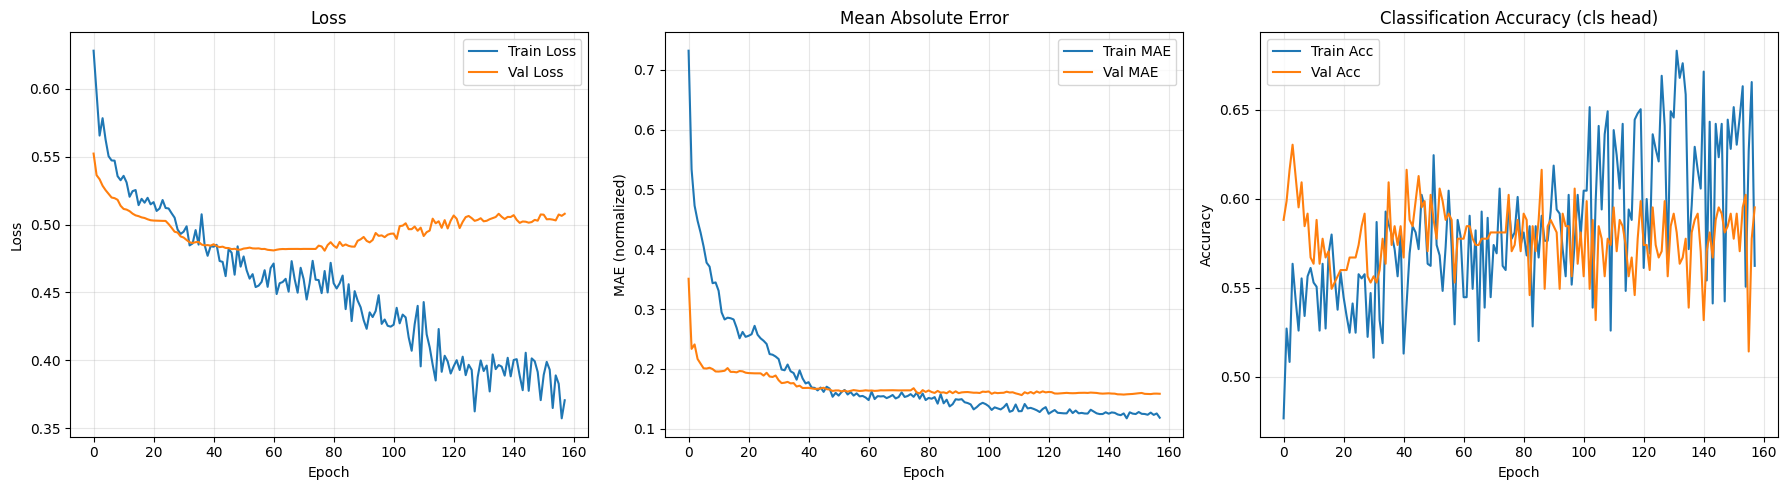

In [14]:
# Cell 13: Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(val_losses, label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_maes, label="Train MAE")
axes[1].plot(val_maes, label="Val MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (normalized)")
axes[1].set_title("Mean Absolute Error")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(train_accs, label="Train Acc")
axes[2].plot(val_accs, label="Val Acc")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].set_title("Classification Accuracy (cls head)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

VALIDATION — method comparison:
  Classification head:           0.5845
  Regression → original thresh:  0.6338
  Regression → midpoint thresh:  0.4577
  Regression → optimized thresh: 0.6585  (t1=0.245, t2=0.687)

TEST SET EVALUATION — MULTI-TASK MODEL
  Classification head:           0.6351
  Regression → original thresh:  0.6491
  Regression → midpoint thresh:  0.4702
  Regression → optimized thresh: 0.6596  (t1=0.245, t2=0.687)

→ Best: reg_optimized with accuracy 0.6596

CLASSIFICATION REPORT — reg_optimized
              precision    recall  f1-score   support

     Class 0       0.62      0.20      0.30        50
     Class 1       0.66      0.96      0.78       183
     Class 2       0.60      0.06      0.11        52

    accuracy                           0.66       285
   macro avg       0.63      0.40      0.40       285
weighted avg       0.64      0.66      0.58       285



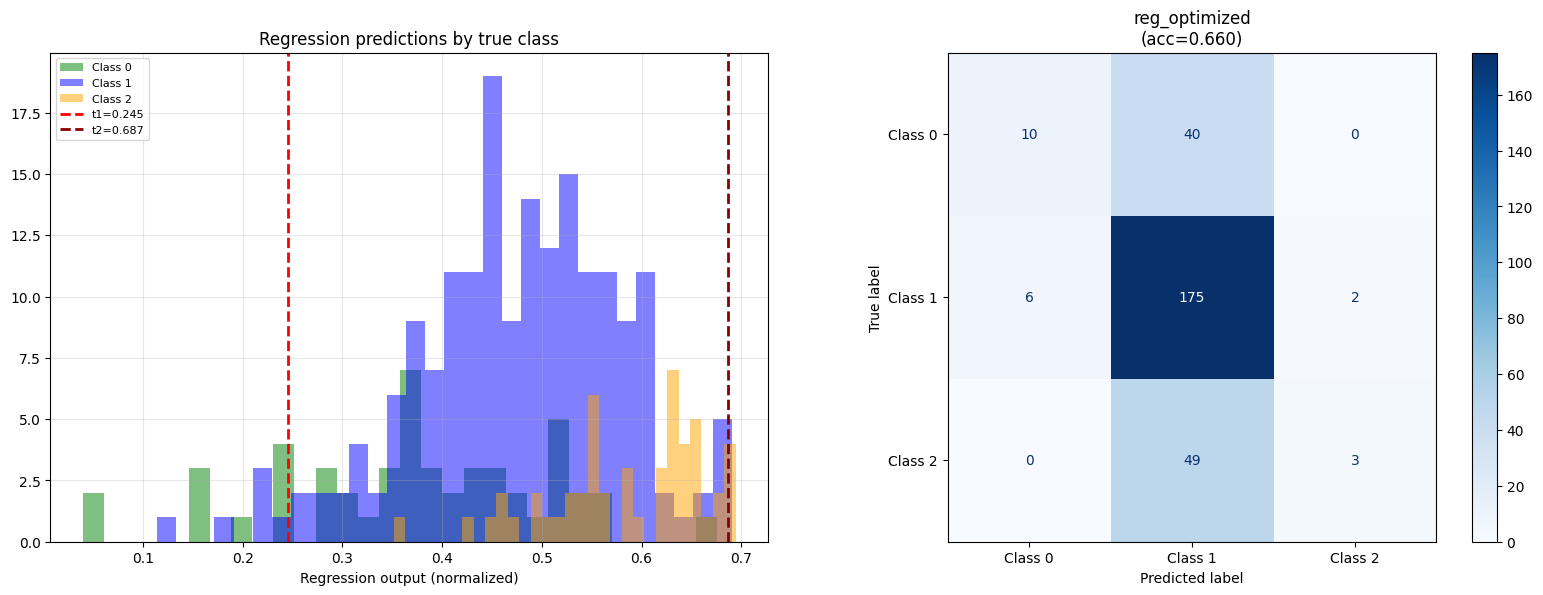

In [15]:
# Cell 14: Evaluate on test set — MULTI-TASK with threshold tuning on regression output
model.eval()

# ── Step 1: Validation predictions for threshold optimization ──
val_reg_preds, val_cls_pred, val_cls_true = [], [], []
with torch.no_grad():
    for X_batch, y_cont_batch, y_cls_batch in val_loader:
        X_batch = X_batch.to(DEVICE)
        reg_pred, cls_pred = model(X_batch)
        val_reg_preds.extend(reg_pred.cpu().numpy())
        val_cls_pred.extend(cls_pred.argmax(dim=1).cpu().numpy())
        val_cls_true.extend(y_cls_batch.numpy())

val_reg_preds = np.array(val_reg_preds)
val_cls_pred = np.array(val_cls_pred)
val_cls_true = np.array(val_cls_true)

# Method 1: Classification head directly
cls_head_acc = (val_cls_pred == val_cls_true).mean()

# Method 2: Regression with original thresholds
reg_cls_acc = (cont_to_class(val_reg_preds) == val_cls_true).mean()

# Method 3: Regression with midpoint thresholds (class centers)
class_centers = np.array([
    val_reg_preds[val_cls_true == c].mean() if (val_cls_true == c).any() else t
    for c, t in enumerate([0, thresh_01_norm, 1])
])
mid_t01 = (class_centers[0] + class_centers[1]) / 2
mid_t12 = (class_centers[1] + class_centers[2]) / 2
mid_val_preds = np.where(val_reg_preds < mid_t01, 0, np.where(val_reg_preds < mid_t12, 1, 2))
mid_val_acc = (mid_val_preds == val_cls_true).mean()

# Method 4: Sweep regression thresholds on validation set
best_val_acc = 0
opt_t1_raw, opt_t2_raw = thresh_01_norm, thresh_12_norm
for t1 in np.linspace(0.0, 1.0, 201):
    for t2 in np.linspace(t1 + 0.01, 1.0, 201):
        preds = np.where(val_reg_preds < t1, 0, np.where(val_reg_preds < t2, 1, 2))
        acc = (preds == val_cls_true).mean()
        if acc > best_val_acc:
            best_val_acc = acc
            opt_t1_raw, opt_t2_raw = t1, t2

val_preds_opt = np.where(val_reg_preds < opt_t1_raw, 0, np.where(val_reg_preds < opt_t2_raw, 1, 2))

print(f"VALIDATION — method comparison:")
print(f"  Classification head:           {cls_head_acc:.4f}")
print(f"  Regression → original thresh:  {reg_cls_acc:.4f}")
print(f"  Regression → midpoint thresh:  {mid_val_acc:.4f}")
print(f"  Regression → optimized thresh: {best_val_acc:.4f}  (t1={opt_t1_raw:.3f}, t2={opt_t2_raw:.3f})")

# ── Step 2: Test set ──
all_reg_preds, all_cls_logits, all_labels_cls = [], [], []
with torch.no_grad():
    for X_batch, y_cont_batch, y_cls_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        reg_pred, cls_pred = model(X_batch)
        all_reg_preds.extend(reg_pred.cpu().numpy())
        all_cls_logits.extend(cls_pred.cpu().numpy())
        all_labels_cls.extend(y_cls_batch.numpy())

all_reg_preds = np.array(all_reg_preds)
all_cls_logits = np.array(all_cls_logits)
all_labels_cls = np.array(all_labels_cls)

# Classification head predictions
cls_head_preds = all_cls_logits.argmax(axis=1)
cls_head_acc = accuracy_score(all_labels_cls, cls_head_preds)

# Regression-based predictions (original thresholds)
reg_cls_acc = accuracy_score(all_labels_cls, cont_to_class(all_reg_preds))

# Regression with midpoint thresholds
reg_mid_preds = np.where(all_reg_preds < mid_t01, 0, np.where(all_reg_preds < mid_t12, 1, 2))
reg_mid_acc = accuracy_score(all_labels_cls, reg_mid_preds)

# Regression with optimized thresholds
reg_opt_preds = np.where(all_reg_preds < opt_t1_raw, 0, np.where(all_reg_preds < opt_t2_raw, 1, 2))
reg_opt_acc = accuracy_score(all_labels_cls, reg_opt_preds)

print(f"\n{'=' * 60}")
print("TEST SET EVALUATION — MULTI-TASK MODEL")
print("=" * 60)
print(f"  Classification head:           {cls_head_acc:.4f}")
print(f"  Regression → original thresh:  {reg_cls_acc:.4f}")
print(f"  Regression → midpoint thresh:  {reg_mid_acc:.4f}")
print(f"  Regression → optimized thresh: {reg_opt_acc:.4f}  (t1={opt_t1_raw:.3f}, t2={opt_t2_raw:.3f})")

# Pick best method
methods = [
    ("cls_head", cls_head_acc, cls_head_preds),
    ("reg_original", reg_cls_acc, cont_to_class(all_reg_preds)),
    ("reg_midpoint", reg_mid_acc, reg_mid_preds),
    ("reg_optimized", reg_opt_acc, reg_opt_preds),
]
best_method = max(methods, key=lambda m: m[1])
best_name, best_acc, all_preds_cls = best_method
print(f"\n→ Best: {best_name} with accuracy {best_acc:.4f}")

print(f"\n{'=' * 60}")
print(f"CLASSIFICATION REPORT — {best_name}")
print("=" * 60)
print(classification_report(all_labels_cls, all_preds_cls, target_names=["Class 0", "Class 1", "Class 2"]))

# ── Plots ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.hist(all_reg_preds[all_labels_cls == 0], bins=30, alpha=0.5, label='Class 0', color='green')
ax1.hist(all_reg_preds[all_labels_cls == 1], bins=30, alpha=0.5, label='Class 1', color='blue')
ax1.hist(all_reg_preds[all_labels_cls == 2], bins=30, alpha=0.5, label='Class 2', color='orange')
ax1.axvline(opt_t1_raw, color='red', ls='--', lw=2, label=f't1={opt_t1_raw:.3f}')
ax1.axvline(opt_t2_raw, color='darkred', ls='--', lw=2, label=f't2={opt_t2_raw:.3f}')
ax1.set_xlabel("Regression output (normalized)")
ax1.set_title("Regression predictions by true class")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

cm = confusion_matrix(all_labels_cls, all_preds_cls)
disp = ConfusionMatrixDisplay(cm, display_labels=["Class 0", "Class 1", "Class 2"])
disp.plot(ax=ax2, cmap="Blues")
ax2.set_title(f"{best_name}\n(acc={best_acc:.3f})")

plt.tight_layout()
plt.show()

Top 15 DB25 codes by embedding magnitude:
   1. DB25 682030 — norm: 4.411
   2. DB25 853260 — norm: 4.258
   3. DB25 722000 — norm: 4.163
   4. DB25 742000 — norm: 4.133
   5. DB25 889150 — norm: 4.070
   6. DB25 747010 — norm: 3.976
   7. DB25 321200 — norm: 3.898
   8. DB25 889910 — norm: 3.893
   9. DB25 702040 — norm: 3.867
  10. DB25 702000 — norm: 3.847
  11. DB25 748490 — norm: 3.826
  12. DB25 931200 — norm: 3.800
  13. DB25 479119 — norm: 3.747
  14. DB25 821100 — norm: 3.732
  15. DB25 620200 — norm: 3.714


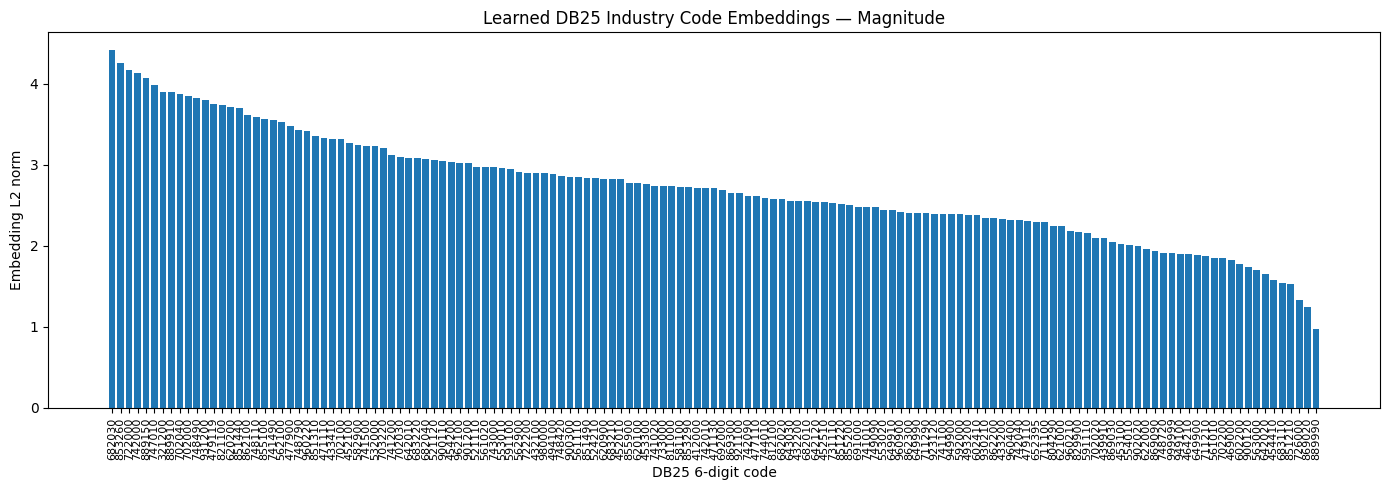

In [16]:
# Cell 15: DB25 embedding analysis — which industry codes matter most?
if hasattr(model, "db25_embedding"):
    with torch.no_grad():
        embeds = model.db25_embedding.weight.cpu().numpy()  # (num_db25, embed_dim)
    
    # Norm of each embedding = proxy for importance
    norms = np.linalg.norm(embeds, axis=1)
    order = np.argsort(norms)[::-1]
    
    print("Top 15 DB25 codes by embedding magnitude:")
    for rank, idx in enumerate(order[:15], 1):
        code = idx2db25[idx]
        print(f"  {rank:2d}. DB25 {code} — norm: {norms[idx]:.3f}")
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 5))
    codes = [idx2db25[i] for i in order]
    ax.bar(range(len(norms)), norms[order])
    ax.set_xticks(range(len(norms)))
    ax.set_xticklabels(codes, rotation=90, fontsize=8)
    ax.set_xlabel("DB25 6-digit code")
    ax.set_ylabel("Embedding L2 norm")
    ax.set_title("Learned DB25 Industry Code Embeddings — Magnitude")
    plt.tight_layout()
    plt.show()

In [17]:
# Cell 16: Save model & predictions (multi-task regression + classification)
MODEL_OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save({
    "model_state_dict": model.state_dict(),
    "db25idx": db25idx,
    "feature_cols": aug_feature_cols,
    "scaler_min": scaler.data_min_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "target_min": float(y_train_min),
    "target_max": float(y_train_max),
    "thresh_01": float(thresh_01),
    "thresh_12": float(thresh_12),
    "config": {
        "input_dim": INPUT_DIM,
        "hidden_dim": HIDDEN_DIM,
        "num_layers": NUM_LAYERS,
        "num_db25": NUM_DB25,
        "embed_dim": EMBED_DIM,
        "dropout": DROPOUT,
        "num_classes": NUM_CLASSES,
        "task": "multi-task regression + classification",
    },
}, MODEL_OUT_PATH)
print(f"Model saved to {MODEL_OUT_PATH}")

# Save predictions for all clusters (using classification head directly)
all_cluster_preds = []
model.eval()
with torch.no_grad():
    for split_name, clusters_list in [("train", train_clusters),
                                       ("val", val_clusters),
                                       ("test", test_clusters)]:
        X_split = build_sequences(clusters_list)
        reg_pred, cls_pred = model(X_split.to(DEVICE))
        reg_pred = reg_pred.cpu().numpy()
        preds_raw = reg_pred * (y_train_max - y_train_min) + y_train_min
        preds_cls = cls_pred.argmax(dim=1).cpu().numpy()
        
        for cid, pred_score, pred_class in zip(clusters_list, preds_raw, preds_cls):
            all_cluster_preds.append({
                "cluster_id": cid,
                "predicted_score": float(pred_score),
                "prediction": int(pred_class),
                "actual_score": float(target_map_cont[cid]),
                "actual_class": int(target_map[cid]),
                "split": split_name,
            })

pred_df = pd.DataFrame(all_cluster_preds)
pred_df.to_csv(PRED_OUT_PATH, index=False)
print(f"Predictions saved to {PRED_OUT_PATH} ({len(pred_df)} clusters)")
print(f"\nClassification accuracy (cls head): {(pred_df['prediction'] == pred_df['actual_class']).mean():.4f}")
print(f"Score MAE: {(pred_df['predicted_score'] - pred_df['actual_score']).abs().mean():.4f}")
pred_df.head(10)

Model saved to ..\results\models\lstm_gentrification.pt
Predictions saved to ..\results\models\lstm_predictions.csv (1421 clusters)

Classification accuracy (cls head): 0.7389
Score MAE: 0.3369


,cluster_id,predicted_score,prediction,actual_score,actual_class,split
0,101_68,2.933167,2,3.499334,2,train
1,101_558,2.877031,2,2.855548,1,train
2,101_621,2.273142,0,2.127458,0,train
3,147_150,2.828366,1,3.128790,1,train
4,101_185,2.461140,0,2.194435,1,train
5,147_105,2.715860,1,2.758248,1,train
6,101_456,2.271263,0,3.156614,1,train
7,101_713,2.505903,1,2.623792,1,train
8,101_71,2.711378,1,2.962346,1,train
9,101_1001,2.596831,1,3.546818,2,train
